In [1]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque

# --- CONFIGURATION ---
ENV_NAME = "LunarLander-v3"
GAMMA = 0.99
BATCH_SIZE = 64
LR = 1e-3
EPSILON_START = 1.0
EPSILON_END = 0.05
EPSILON_DECAY = 0.995
MEMORY_SIZE = 100000
TRAIN_EPISODES = 1000  # Adjust as needed (usually takes 400-600 to solve)

# --- 1. THE WRAPPER (CRITICAL FOR YOUR EXPERIMENT) ---
class RemoveDoNothingWrapper(gym.ActionWrapper):
    """
    Changes the action space from 4 to 3.
    Maps agent actions (0, 1, 2) to environment actions (1, 2, 3).
    
    Agent Action 0 -> Env Action 1 (Fire Left Engine)
    Agent Action 1 -> Env Action 2 (Fire Main Engine)
    Agent Action 2 -> Env Action 3 (Fire Right Engine)
    
    The 'Do Nothing' (Env Action 0) is effectively removed.
    """
    def __init__(self, env):
        super().__init__(env)
        # We tell the agent there are only 3 actions available
        self.action_space = gym.spaces.Discrete(3)
    
    def action(self, action):
        # We shift the action by +1 to skip '0' (Do Nothing)
        return action + 1

# --- 2. THE NETWORK (DQN) ---
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(QNetwork, self).__init__()
        # Simple MLP: Input -> 64 -> 64 -> Output
        self.fc1 = nn.Linear(state_dim, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, action_dim)
        
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

# --- 3. THE AGENT ---
class DQNAgent:
    def __init__(self, state_dim, action_dim):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.memory = deque(maxlen=MEMORY_SIZE)
        self.epsilon = EPSILON_START
        
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
        # Policy Network (The one we train)
        self.policy_net = QNetwork(state_dim, action_dim).to(self.device)
        # Target Network (For stability)
        self.target_net = QNetwork(state_dim, action_dim).to(self.device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=LR)
        self.loss_fn = nn.MSELoss()

    def select_action(self, state):
        # Epsilon-Greedy Strategy
        if random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)
        else:
            with torch.no_grad():
                state_t = torch.FloatTensor(state).unsqueeze(0).to(self.device)
                q_values = self.policy_net(state_t)
                return q_values.argmax().item()

    def store_transition(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def train_step(self):
        if len(self.memory) < BATCH_SIZE:
            return
        
        batch = random.sample(self.memory, BATCH_SIZE)
        states, actions, rewards, next_states, dones = zip(*batch)
        
        states = torch.FloatTensor(np.array(states)).to(self.device)
        actions = torch.LongTensor(actions).unsqueeze(1).to(self.device)
        rewards = torch.FloatTensor(rewards).unsqueeze(1).to(self.device)
        next_states = torch.FloatTensor(np.array(next_states)).to(self.device)
        dones = torch.FloatTensor(dones).unsqueeze(1).to(self.device)

        # Q(s, a)
        curr_q = self.policy_net(states).gather(1, actions)
        
        # Max Q(s', a') from target net
        next_q = self.target_net(next_states).max(1)[0].unsqueeze(1)
        target_q = rewards + (GAMMA * next_q * (1 - dones))
        
        loss = self.loss_fn(curr_q, target_q)
        
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def update_epsilon(self):
        self.epsilon = max(EPSILON_END, self.epsilon * EPSILON_DECAY)
        
    def update_target_network(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())

# --- 4. MAIN TRAINING LOOP ---
if __name__ == "__main__":
    # Create environment with the wrapper
    raw_env = gym.make(ENV_NAME) # render_mode="human" if you want to watch
    env = RemoveDoNothingWrapper(raw_env)
    
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n # This will be 3
    
    agent = DQNAgent(state_dim, action_dim)
    
    print(f"Training on {ENV_NAME} with {action_dim} actions (No 'Do Nothing')...")
    
    scores = []
    
    for episode in range(TRAIN_EPISODES):
        state, _ = env.reset()
        total_reward = 0
        done = False
        truncated = False
        
        while not (done or truncated):
            action = agent.select_action(state)
            next_state, reward, done, truncated, _ = env.step(action)
            
            agent.store_transition(state, action, reward, next_state, done or truncated)
            agent.train_step()
            
            state = next_state
            total_reward += reward
            
        agent.update_epsilon()
        
        # Update target network every 10 episodes
        if episode % 10 == 0:
            agent.update_target_network()
            
        scores.append(total_reward)
        avg_score = np.mean(scores[-100:])
        
        if episode % 10 == 0:
            print(f"Episode {episode} | Score: {total_reward:.2f} | Avg (100): {avg_score:.2f} | Epsilon: {agent.epsilon:.2f}")

        # Check for convergence (Lower threshold because fuel is expensive without coasting)
        # Normal solved is 200, but without 'Do Nothing', 100-150 is often a very good landing.
        if avg_score > 80:
            print(f"--- CONVERGED AT EPISODE {episode} ---")
            torch.save(agent.policy_net.state_dict(), "phase1_model.pth")
            break

    env.close()
    print("Training Complete. Model saved as 'phase1_model.pth'")

Training on LunarLander-v3 with 3 actions (No 'Do Nothing')...
Episode 0 | Score: -368.75 | Avg (100): -368.75 | Epsilon: 0.99
Episode 10 | Score: -68.98 | Avg (100): -182.89 | Epsilon: 0.95
Episode 20 | Score: -57.45 | Avg (100): -188.79 | Epsilon: 0.90
Episode 30 | Score: -144.08 | Avg (100): -189.43 | Epsilon: 0.86
Episode 40 | Score: -137.78 | Avg (100): -175.55 | Epsilon: 0.81
Episode 50 | Score: -126.62 | Avg (100): -165.98 | Epsilon: 0.77
Episode 60 | Score: -35.61 | Avg (100): -158.05 | Epsilon: 0.74
Episode 70 | Score: -203.69 | Avg (100): -153.70 | Epsilon: 0.70
Episode 80 | Score: -41.00 | Avg (100): -145.39 | Epsilon: 0.67
Episode 90 | Score: -259.37 | Avg (100): -142.10 | Epsilon: 0.63
Episode 100 | Score: -71.99 | Avg (100): -134.32 | Epsilon: 0.60
Episode 110 | Score: -36.21 | Avg (100): -125.06 | Epsilon: 0.57
Episode 120 | Score: -30.18 | Avg (100): -111.71 | Epsilon: 0.55
Episode 130 | Score: -33.34 | Avg (100): -98.37 | Epsilon: 0.52
Episode 140 | Score: -179.97 | Av

In [2]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque
import copy

# --- CONFIGURATION ---
ENV_NAME = "LunarLander-v3"
GAMMA = 0.99
BATCH_SIZE = 64
LR_Q = 1e-3
LR_MODEL = 1e-3  # Learning rate for the Partial Model
MEMORY_SIZE = 100000
TRAIN_EPISODES = 600

# --- 1. THE PARTIAL MODEL (The "Learned Oracle") ---
class PartialModel(nn.Module):
    """
    Predicts the next state s' given state s, specifically for Action 0 (Do Nothing).
    Input: State Dim (8)
    Output: State Dim (8)
    """
    def __init__(self, state_dim):
        super(PartialModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, state_dim) # Output is the predicted next state vector
        )

    def forward(self, x):
        return self.net(x)

# --- 2. THE Q-NETWORK (Modified for Transfer) ---
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, action_dim)
        
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

# --- 3. THE ADAPTIVE AGENT ---
class AdaptiveAgent:
    def __init__(self, state_dim, old_action_dim, new_action_dim, model_path="phase1_model.pth"):
        self.state_dim = state_dim
        self.action_dim = new_action_dim # Now 4 actions
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
        # A. Initialize Networks
        # 1. Old Policy (Frozen, used for value estimation V_old)
        self.old_net = QNetwork(state_dim, old_action_dim).to(self.device)
        self.old_net.load_state_dict(torch.load(model_path))
        self.old_net.eval() # Freeze it
        
        # 2. New Policy (The one we will train)
        self.policy_net = QNetwork(state_dim, new_action_dim).to(self.device)
        self.target_net = QNetwork(state_dim, new_action_dim).to(self.device)
        
        # B. TRANSFER LEARNING (Copy weights)
        # We copy the weights from the old 3-action net to the new 4-action net
        # The 4th output neuron (Action 0) will be initialized randomly/optimistically
        with torch.no_grad():
            self.policy_net.fc1.weight.copy_(self.old_net.fc1.weight)
            self.policy_net.fc1.bias.copy_(self.old_net.fc1.bias)
            self.policy_net.fc2.weight.copy_(self.old_net.fc2.weight)
            self.policy_net.fc2.bias.copy_(self.old_net.fc2.bias)
            
            # For the output layer, we copy the first 3 rows (Actions 1,2,3)
            # Note: In Phase 1 code, Agent Action 0,1,2 mapped to Env 1,2,3.
            # In Phase 2, Agent Action 0 is NEW. Agent 1,2,3 are OLD.
            # So we map Old Agent 0->New 1, Old 1->New 2, Old 2->New 3.
            self.policy_net.fc3.weight[1:4] = self.old_net.fc3.weight[0:3]
            self.policy_net.fc3.bias[1:4] = self.old_net.fc3.bias[0:3]
            
            # Optimistic Initialization for New Action (0) [Cite: 9, 116]
            # We initialize the weights for action 0 to be similar to the best existing action
            # (Simplified here as random small values, but you can copy the mean of others)
            
        self.target_net.load_state_dict(self.policy_net.state_dict())
        
        # 3. The Partial Model (To be learned)
        self.partial_model = PartialModel(state_dim).to(self.device)
        self.model_optimizer = optim.Adam(self.partial_model.parameters(), lr=LR_MODEL)
        self.model_loss_fn = nn.MSELoss()
        
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=LR_Q)
        self.loss_fn = nn.MSELoss()
        
        self.memory = deque(maxlen=MEMORY_SIZE)
        self.epsilon = 0.1 # Start low, we are adapting, not learning from scratch

    def select_action(self, state):
        # Epsilon Greedy
        if random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)
            
        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0).to(self.device)
            
            # --- ACTION FILTERING (The Core of Your Paper) ---
            # 1. Get Q-values for OLD actions (1, 2, 3) from current policy
            q_values = self.policy_net(state_t) # Shape [1, 4]
            
            # 2. Evaluate the New Action (Action 0 - Do Nothing)
            # Use Partial Model to predict next state s'
            pred_next_state = self.partial_model(state_t)
            
            # Calculate Value of current state V(s) using Old Policy (Max Q)
            # We use the OLD NET to judge value, as per paper theory (Reusing V_old)
            q_old_s = self.old_net(state_t)
            v_old_s = q_old_s.max().item()
            
            # Calculate Value of predicted next state V(s') using Old Policy
            q_old_s_prime = self.old_net(pred_next_state)
            v_old_s_prime = q_old_s_prime.max().item()
            
            # Filtering Condition [Cite: 124, Eq 7]: Only allow Action 0 if V(s') > V(s)
            # We add a small threshold (0.05) to account for approximation error
            if v_old_s_prime > v_old_s + 0.05:
                # The model thinks "Do Nothing" leads to a better state!
                # We allow the agent to pick it if it has the highest Q-value
                best_action = q_values.argmax().item()
                return best_action
            else:
                # The model predicts "Do Nothing" is bad/useless.
                # Force agent to pick from Old Actions (1, 2, 3)
                old_actions_q = q_values[0, 1:4] # Slice out action 0
                best_old_idx = old_actions_q.argmax().item()
                return best_old_idx + 1 # +1 because we sliced
                
    def train_step(self):
        if len(self.memory) < BATCH_SIZE:
            return
        
        batch = random.sample(self.memory, BATCH_SIZE)
        states, actions, rewards, next_states, dones = zip(*batch)
        
        states = torch.FloatTensor(np.array(states)).to(self.device)
        actions = torch.LongTensor(actions).unsqueeze(1).to(self.device)
        rewards = torch.FloatTensor(rewards).unsqueeze(1).to(self.device)
        next_states = torch.FloatTensor(np.array(next_states)).to(self.device)
        dones = torch.FloatTensor(dones).unsqueeze(1).to(self.device)

        # --- A. TRAIN PARTIAL MODEL ---
        # We only train the model on transitions where Action 0 was taken
        mask_action_0 = (actions == 0).squeeze()
        if mask_action_0.sum() > 0:
            pred_states = self.partial_model(states[mask_action_0])
            true_next_states = next_states[mask_action_0]
            
            model_loss = self.model_loss_fn(pred_states, true_next_states)
            self.model_optimizer.zero_grad()
            model_loss.backward()
            self.model_optimizer.step()

        # --- B. TRAIN Q-NETWORK (Standard DQN) ---
        curr_q = self.policy_net(states).gather(1, actions)
        next_q = self.target_net(next_states).max(1)[0].unsqueeze(1)
        target_q = rewards + (GAMMA * next_q * (1 - dones))
        
        loss = self.loss_fn(curr_q, target_q)
        
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def store_transition(self, s, a, r, ns, d):
        self.memory.append((s, a, r, ns, d))
    
    def update_target_network(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())

# --- 4. MAIN LOOP ---
if __name__ == "__main__":
    # Standard Environment (4 actions: 0=DoNothing, 1=Left, 2=Main, 3=Right)
    env = gym.make(ENV_NAME) 
    
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n # 4
    
    # Initialize Adaptive Agent
    # Note: old_action_dim=3 because Phase 1 had 3 output neurons
    agent = AdaptiveAgent(state_dim, old_action_dim=3, new_action_dim=4, model_path="phase1_model.pth")
    
    print("Starting Phase 2: Adaptation to New Action (Do Nothing)...")
    
    scores_adaptive = []
    for episode in range(TRAIN_EPISODES):
        state, _ = env.reset()
        total_reward = 0
        done = False
        truncated = False
        
        while not (done or truncated):
            action = agent.select_action(state)
            next_state, reward, done, truncated, _ = env.step(action)
            
            agent.store_transition(state, action, reward, next_state, done or truncated)
            agent.train_step()
            
            state = next_state
            total_reward += reward
            
        if episode % 10 == 0:
            agent.update_target_network()
            
        scores_adaptive.append(total_reward)
        avg_score = np.mean(scores_adaptive[-100:])
        
        if episode % 10 == 0:
            print(f"Episode {episode} | Score: {total_reward:.2f} | Avg: {avg_score:.2f}")

    env.close()

Starting Phase 2: Adaptation to New Action (Do Nothing)...


/var/folders/7y/tb8vlfv937523rgqdlf0zjy40000gn/T/ipykernel_88505/525966700.py:62: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.old_net.load_state_dict(torch.load(model

Episode 0 | Score: 199.20 | Avg: 199.20
Episode 10 | Score: -67.97 | Avg: 56.06
Episode 20 | Score: 275.14 | Avg: 60.26
Episode 30 | Score: 22.37 | Avg: 57.13
Episode 40 | Score: -24.74 | Avg: 62.77
Episode 50 | Score: 147.85 | Avg: 78.01
Episode 60 | Score: 73.24 | Avg: 70.52
Episode 70 | Score: 273.53 | Avg: 70.96
Episode 80 | Score: 22.30 | Avg: 84.76
Episode 90 | Score: 114.68 | Avg: 89.35
Episode 100 | Score: 47.31 | Avg: 82.74
Episode 110 | Score: 142.07 | Avg: 89.67
Episode 120 | Score: -107.39 | Avg: 85.89
Episode 130 | Score: 7.60 | Avg: 85.59
Episode 140 | Score: 107.58 | Avg: 86.59
Episode 150 | Score: 152.98 | Avg: 88.82
Episode 160 | Score: 279.07 | Avg: 94.50
Episode 170 | Score: -88.93 | Avg: 89.39
Episode 180 | Score: -140.12 | Avg: 74.08
Episode 190 | Score: -59.89 | Avg: 74.76
Episode 200 | Score: -315.06 | Avg: 74.85
Episode 210 | Score: 242.19 | Avg: 76.99
Episode 220 | Score: 134.92 | Avg: 92.27
Episode 230 | Score: -103.14 | Avg: 90.82
Episode 240 | Score: 265.64 

In [3]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque

# --- CONFIGURATION (Must match Phase 1 & 2 for fair comparison) ---
ENV_NAME = "LunarLander-v3"
GAMMA = 0.99
BATCH_SIZE = 64
LR = 1e-3
EPSILON_START = 1.0
EPSILON_END = 0.05
EPSILON_DECAY = 0.995
MEMORY_SIZE = 100000
TRAIN_EPISODES = 600

# --- 1. STANDARD Q-NETWORK ---
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, action_dim)
        
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

# --- 2. STANDARD DQN AGENT ---
class DQNAgent:
    def __init__(self, state_dim, action_dim):
        self.action_dim = action_dim
        self.memory = deque(maxlen=MEMORY_SIZE)
        self.epsilon = EPSILON_START
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
        self.policy_net = QNetwork(state_dim, action_dim).to(self.device)
        self.target_net = QNetwork(state_dim, action_dim).to(self.device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=LR)
        self.loss_fn = nn.MSELoss()

    def select_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)
        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0).to(self.device)
            return self.policy_net(state_t).argmax().item()

    def store_transition(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def train_step(self):
        if len(self.memory) < BATCH_SIZE:
            return
        
        batch = random.sample(self.memory, BATCH_SIZE)
        states, actions, rewards, next_states, dones = zip(*batch)
        
        states = torch.FloatTensor(np.array(states)).to(self.device)
        actions = torch.LongTensor(actions).unsqueeze(1).to(self.device)
        rewards = torch.FloatTensor(rewards).unsqueeze(1).to(self.device)
        next_states = torch.FloatTensor(np.array(next_states)).to(self.device)
        dones = torch.FloatTensor(dones).unsqueeze(1).to(self.device)

        curr_q = self.policy_net(states).gather(1, actions)
        next_q = self.target_net(next_states).max(1)[0].unsqueeze(1)
        target_q = rewards + (GAMMA * next_q * (1 - dones))
        
        loss = self.loss_fn(curr_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def update_epsilon(self):
        self.epsilon = max(EPSILON_END, self.epsilon * EPSILON_DECAY)
        
    def update_target_network(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())

# --- 3. MAIN LOOP ---
if __name__ == "__main__":
    # Standard environment with all 4 actions enabled by default
    env = gym.make(ENV_NAME) 
    
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n # Should be 4
    
    agent = DQNAgent(state_dim, action_dim)
    
    print(f"Starting Baseline: Full Training from Scratch ({action_dim} actions)...")
    
    scores = []
    
    for episode in range(TRAIN_EPISODES):
        state, _ = env.reset()
        total_reward = 0
        done = False
        truncated = False
        
        while not (done or truncated):
            action = agent.select_action(state)
            next_state, reward, done, truncated, _ = env.step(action)
            
            agent.store_transition(state, action, reward, next_state, done or truncated)
            agent.train_step()
            
            state = next_state
            total_reward += reward
            
        agent.update_epsilon()
        
        if episode % 10 == 0:
            agent.update_target_network()
            
        scores.append(total_reward)
        avg_score = np.mean(scores[-100:])
        
        if episode % 10 == 0:
            print(f"Episode {episode} | Score: {total_reward:.2f} | Avg: {avg_score:.2f} | Epsilon: {agent.epsilon:.2f}")

    env.close()
    print("Baseline Training Complete.")

Starting Baseline: Full Training from Scratch (4 actions)...
Episode 0 | Score: -139.20 | Avg: -139.20 | Epsilon: 0.99
Episode 10 | Score: -162.84 | Avg: -196.34 | Epsilon: 0.95
Episode 20 | Score: -33.13 | Avg: -168.67 | Epsilon: 0.90
Episode 30 | Score: -104.47 | Avg: -166.51 | Epsilon: 0.86
Episode 40 | Score: -88.49 | Avg: -156.69 | Epsilon: 0.81
Episode 50 | Score: -30.74 | Avg: -147.26 | Epsilon: 0.77
Episode 60 | Score: -66.08 | Avg: -139.20 | Epsilon: 0.74
Episode 70 | Score: -414.55 | Avg: -142.25 | Epsilon: 0.70
Episode 80 | Score: -73.50 | Avg: -132.12 | Epsilon: 0.67
Episode 90 | Score: -79.04 | Avg: -133.98 | Epsilon: 0.63
Episode 100 | Score: -71.04 | Avg: -127.18 | Epsilon: 0.60
Episode 110 | Score: -64.19 | Avg: -113.92 | Epsilon: 0.57
Episode 120 | Score: -81.03 | Avg: -105.60 | Epsilon: 0.55
Episode 130 | Score: 36.99 | Avg: -93.75 | Epsilon: 0.52
Episode 140 | Score: -42.88 | Avg: -85.05 | Epsilon: 0.49
Episode 150 | Score: 7.90 | Avg: -76.16 | Epsilon: 0.47
Episode 

In [4]:
# --- NAIVE AGENT (NO CONDITION) ---
class NaiveAdaptiveAgent:
    def __init__(self, state_dim, old_action_dim, new_action_dim, model_path="phase1_model.pth"):
        self.action_dim = new_action_dim
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
        # 1. Initialize New Network
        self.policy_net = QNetwork(state_dim, new_action_dim).to(self.device)
        self.target_net = QNetwork(state_dim, new_action_dim).to(self.device)
        
        # 2. Load Old Weights (Transfer Learning)
        # We load the 3-action model to initialize the 4-action model
        old_net = QNetwork(state_dim, old_action_dim).to(self.device)
        old_net.load_state_dict(torch.load(model_path))
        
        with torch.no_grad():
            self.policy_net.fc1.weight.copy_(old_net.fc1.weight)
            self.policy_net.fc1.bias.copy_(old_net.fc1.bias)
            self.policy_net.fc2.weight.copy_(old_net.fc2.weight)
            self.policy_net.fc2.bias.copy_(old_net.fc2.bias)
            
            # Transfer output weights: Map Old(0,1,2) -> New(1,2,3)
            self.policy_net.fc3.weight[1:4] = old_net.fc3.weight[0:3]
            self.policy_net.fc3.bias[1:4] = old_net.fc3.bias[0:3]
            
            # Action 0 (Do Nothing) is initialized randomly/optimistically
            # This causes the agent to try it frequently early on
            
        self.target_net.load_state_dict(self.policy_net.state_dict())
        
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=LR_Q)
        self.loss_fn = nn.MSELoss()
        self.memory = deque(maxlen=MEMORY_SIZE)
        self.epsilon = 0.1 # Start with low epsilon (relying on Transfer)

    def select_action(self, state):
        # STANDARD EPSILON GREEDY (No Model Filter)
        if random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)
        
        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0).to(self.device)
            return self.policy_net(state_t).argmax().item()

    def store_transition(self, s, a, r, ns, d):
        self.memory.append((s, a, r, ns, d))

    def train_step(self):
        if len(self.memory) < BATCH_SIZE:
            return
        batch = random.sample(self.memory, BATCH_SIZE)
        states, actions, rewards, next_states, dones = zip(*batch)
        
        states = torch.FloatTensor(np.array(states)).to(self.device)
        actions = torch.LongTensor(actions).unsqueeze(1).to(self.device)
        rewards = torch.FloatTensor(rewards).unsqueeze(1).to(self.device)
        next_states = torch.FloatTensor(np.array(next_states)).to(self.device)
        dones = torch.FloatTensor(dones).unsqueeze(1).to(self.device)

        curr_q = self.policy_net(states).gather(1, actions)
        next_q = self.target_net(next_states).max(1)[0].unsqueeze(1)
        target_q = rewards + (GAMMA * next_q * (1 - dones))
        
        loss = self.loss_fn(curr_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
    
    def update_target_network(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())

if __name__ == "__main__":
    env = gym.make(ENV_NAME)
    state_dim = env.observation_space.shape[0]
    
    # Run the "No Condition" Experiment
    agent = NaiveAdaptiveAgent(state_dim, old_action_dim=3, new_action_dim=4, model_path="phase1_model.pth")
    
    print("Starting Ablation: Naive Adaptation (No Condition)...")
    scores_naive = []
    
    for episode in range(TRAIN_EPISODES):
        state, _ = env.reset()
        total_reward = 0
        done = False
        truncated = False
        
        while not (done or truncated):
            action = agent.select_action(state)
            next_state, reward, done, truncated, _ = env.step(action)
            agent.store_transition(state, action, reward, next_state, done or truncated)
            agent.train_step()
            state = next_state
            total_reward += reward
            
        if episode % 10 == 0:
            agent.update_target_network()
            
        scores_naive.append(total_reward)
        if episode % 10 == 0:
            print(f"Episode {episode} | Score: {total_reward:.2f}")

    print("Ablation Complete.")

Starting Ablation: Naive Adaptation (No Condition)...
Episode 0 | Score: 27.73


/var/folders/7y/tb8vlfv937523rgqdlf0zjy40000gn/T/ipykernel_88505/3742331668.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  old_net.load_state_dict(torch.load(model_pat

Episode 10 | Score: 255.23
Episode 20 | Score: -8.71
Episode 30 | Score: 236.08
Episode 40 | Score: -82.18
Episode 50 | Score: 201.69
Episode 60 | Score: -176.31
Episode 70 | Score: -30.56
Episode 80 | Score: 35.88
Episode 90 | Score: -95.55
Episode 100 | Score: -30.36
Episode 110 | Score: -121.13
Episode 120 | Score: -54.12
Episode 130 | Score: 217.01
Episode 140 | Score: 233.12
Episode 150 | Score: 286.46
Episode 160 | Score: 124.32
Episode 170 | Score: -9.36
Episode 180 | Score: 160.38
Episode 190 | Score: 175.58
Episode 200 | Score: 240.75
Episode 210 | Score: 242.86
Episode 220 | Score: 255.52
Episode 230 | Score: 195.86
Episode 240 | Score: 246.32
Episode 250 | Score: 243.83
Episode 260 | Score: 259.91
Episode 270 | Score: 47.01
Episode 280 | Score: 242.79
Episode 290 | Score: 95.19
Episode 300 | Score: 185.06
Episode 310 | Score: 306.59
Episode 320 | Score: 7.95
Episode 330 | Score: 225.28
Episode 340 | Score: 243.82
Episode 350 | Score: -282.82
Episode 360 | Score: 151.40
Episo

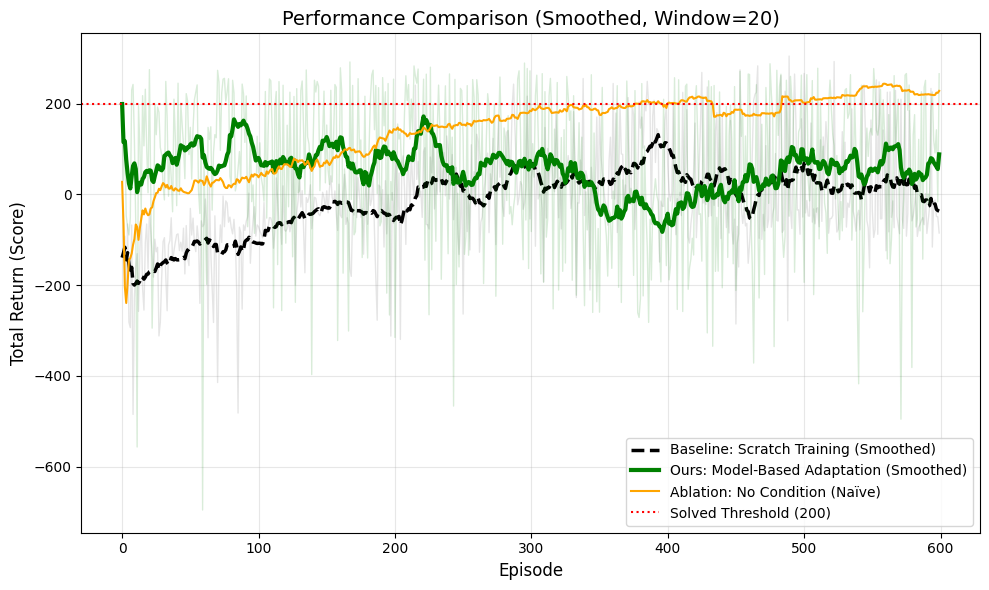

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd  # Import pandas for easy rolling average

# --- 1. Define a Smoothing Function ---
def smooth(data, window_size=50):
    """
    Calculates the rolling average.
    window_size: Number of episodes to average over (higher = smoother)
    """
    series = pd.Series(data)
    return series.rolling(window=window_size, min_periods=1).mean()

# --- 2. Create the Plot ---
plt.figure(figsize=(10, 6))

# Define window size (Adjust this! 20-50 is usually good for 600 episodes)
WINDOW = 20

# --- Plot Baseline (Scratch) ---
# Optional: Plot raw data faintly in background
plt.plot(scores, color='gray', alpha=0.2, linewidth=1) 
# Plot smoothed trend line
plt.plot(smooth(scores, WINDOW), color='black', linestyle='--', linewidth=2.5, label='Baseline: Scratch Training (Smoothed)')

# --- Plot Ours (Adaptive) ---
# Optional: Plot raw data faintly in background
plt.plot(scores_adaptive, color='green', alpha=0.15, linewidth=1)
# Plot smoothed trend line
plt.plot(smooth(scores_adaptive, WINDOW), color='green', linewidth=3, label='Ours: Model-Based Adaptation (Smoothed)')
plt.plot(smooth(scores_naive), color='orange', label='Ablation: No Condition (Naïve)')
# --- Formatting ---
plt.xlabel('Episode', fontsize=12)
plt.ylabel('Total Return (Score)', fontsize=12)
plt.title(f'Performance Comparison (Smoothed, Window={WINDOW})', fontsize=14)
plt.axhline(y=200, color='red', linestyle=':', label='Solved Threshold (200)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()